# 02 — Liver Steatosis Binary Model (Proof of Concept)

Binary classification: can Whole Blood expression predict liver steatosis?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache
from gtex_biomarkers.models import run_cv, make_lr_pipeline
from gtex_biomarkers.evaluation import plot_roc_folds

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, blood_meta, df_meta_url, df_age = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## Create Steatosis Label from Pathology Metadata

In [2]:
liver_path = df_meta_url.loc[
    df_meta_url["Tissue"].astype(str) == "Liver",
    ["Tissue.Sample.ID", "Tissue", "Pathology.Categories", "Pathology.Notes"]
].copy()
liver_path = liver_path.rename(columns={"Tissue.Sample.ID": "SAMPID"})

text = (
    liver_path["Pathology.Categories"].fillna("").astype(str) + " " +
    liver_path["Pathology.Notes"].fillna("").astype(str)
)
liver_path["steatosis_label"] = text.str.contains("steatosis", case=False).astype(int)
liver_path["SUBJID"] = liver_path["SAMPID"].astype(str).str.split("-").str[:2].str.join("-")
donor_steatosis = liver_path.groupby("SUBJID")["steatosis_label"].max()

print("Donors with steatosis label:")
print(donor_steatosis.value_counts())

Donors with steatosis label:
steatosis_label
0    329
1    281
Name: count, dtype: int64


## Build Labeled Blood Dataset

In [3]:
y = blood_subjid.map(donor_steatosis)
keep = y.notna()
X_features = X_wb.loc[keep].copy()
y = y.loc[keep].astype(int)
groups = blood_subjid.loc[keep].astype(str)

print(f"Labeled blood samples: {X_features.shape[0]}")
print(f"Features (genes): {X_features.shape[1]}")
print(f"Label distribution:\n{y.value_counts()}")

Labeled blood samples: 487
Features (genes): 59033
Label distribution:
0    260
1    227
Name: count, dtype: int64


## Run 5-Fold Grouped CV

In [4]:
results = run_cv(X_features, y, groups, make_lr_pipeline)

print(f"Mean AUC: {results['mean_auc']:.3f} ± {results['std_auc']:.3f}")
for i, a in enumerate(results['fold_aucs'], 1):
    print(f"  Fold {i}: AUC = {a:.3f}")

Mean AUC: 0.575 ± 0.048
  Fold 1: AUC = 0.640
  Fold 2: AUC = 0.595
  Fold 3: AUC = 0.591
  Fold 4: AUC = 0.494
  Fold 5: AUC = 0.555


## ROC Curves

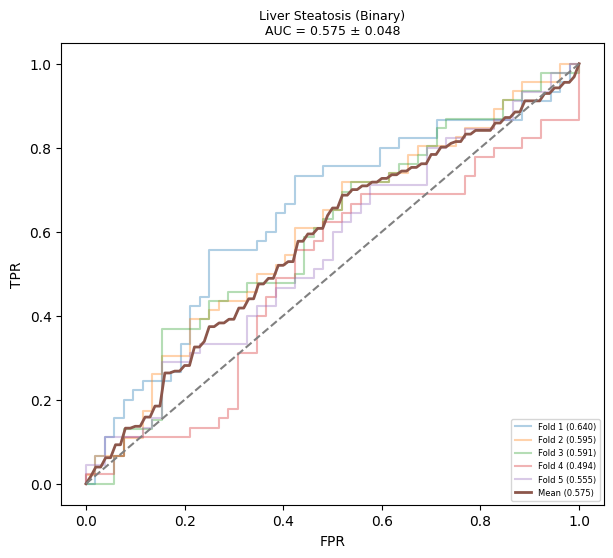

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc_folds(results, title="Liver Steatosis (Binary)", ax=ax)
fig.savefig(Config.FIGURES_DIR / "roc_curves_5fold.pdf", bbox_inches="tight")
plt.show()